In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [219]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [221]:
df.shape

(7043, 21)

In [222]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [223]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [224]:
df.duplicated().sum()

np.int64(0)

In [225]:
df=df.drop('customerID',axis=1)

In [226]:
df.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [227]:
df['Partner']=df['Partner'].map({'Yes':1,'No':0})
df['Dependents']=df['Dependents'].map({'Yes':1,'No':0})
df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df['PaperlessBilling']=df['PaperlessBilling'].map({'Yes':1,'No':0})
df['PhoneService']=df['PhoneService'].map({'Yes':1,'No':0})
df['gender']=df['gender'].map({'Male':1,'Female':0})

In [228]:
cat_cols=list(df.select_dtypes(include='object').columns)

In [229]:
for col in cat_cols:
  print(f'{col}: {df[col].unique()}')

MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']


In [230]:
df['MultipleLines']=df['MultipleLines'].map({'Yes':1,'No':0,'No phone service':2})
df['OnlineSecurity']=df['OnlineSecurity'].map({'Yes':1,'No':0,'No internet service':2})
df['OnlineBackup']=df['OnlineBackup'].map({'Yes':1,'No':0,'No internet service':2})
df['DeviceProtection']=df['DeviceProtection'].map({'Yes':1,'No':0,'No internet service':2})
df['TechSupport']=df['TechSupport'].map({'Yes':1,'No':0,'No internet service':2})
df['StreamingTV']=df['StreamingTV'].map({'Yes':1,'No':0,'No internet service':2})
df['StreamingMovies']=df['StreamingMovies'].map({'Yes':1,'No':0,'No internet service':2})
df['Contract']=df['Contract'].map({'Month-to-month':1,'One year':2,'Two year':3})

In [231]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [232]:
num_cols=list(df.select_dtypes(include='number').columns)
num_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [233]:
encoder = OneHotEncoder(sparse_output=False)

# 2. Fit + transform the categorical column
encoded_array = encoder.fit_transform(df[['PaymentMethod']])

# 3. Convert result back to DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['PaymentMethod'])
)

# 4. Remove original column and add encoded columns
df = pd.concat(
    [df.drop('PaymentMethod', axis=1), encoded_df],
    axis=1
)

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   InternetService                          7043 non-null   object 
 8   OnlineSecurity                           7043 non-null   int64  
 9   OnlineBackup                             7043 non-null   int64  
 10  DeviceProtection                         7043 no

In [235]:
df['TotalCharges'].head()

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65


In [236]:
nums_col_df=df.select_dtypes(include='number')
nums_col_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

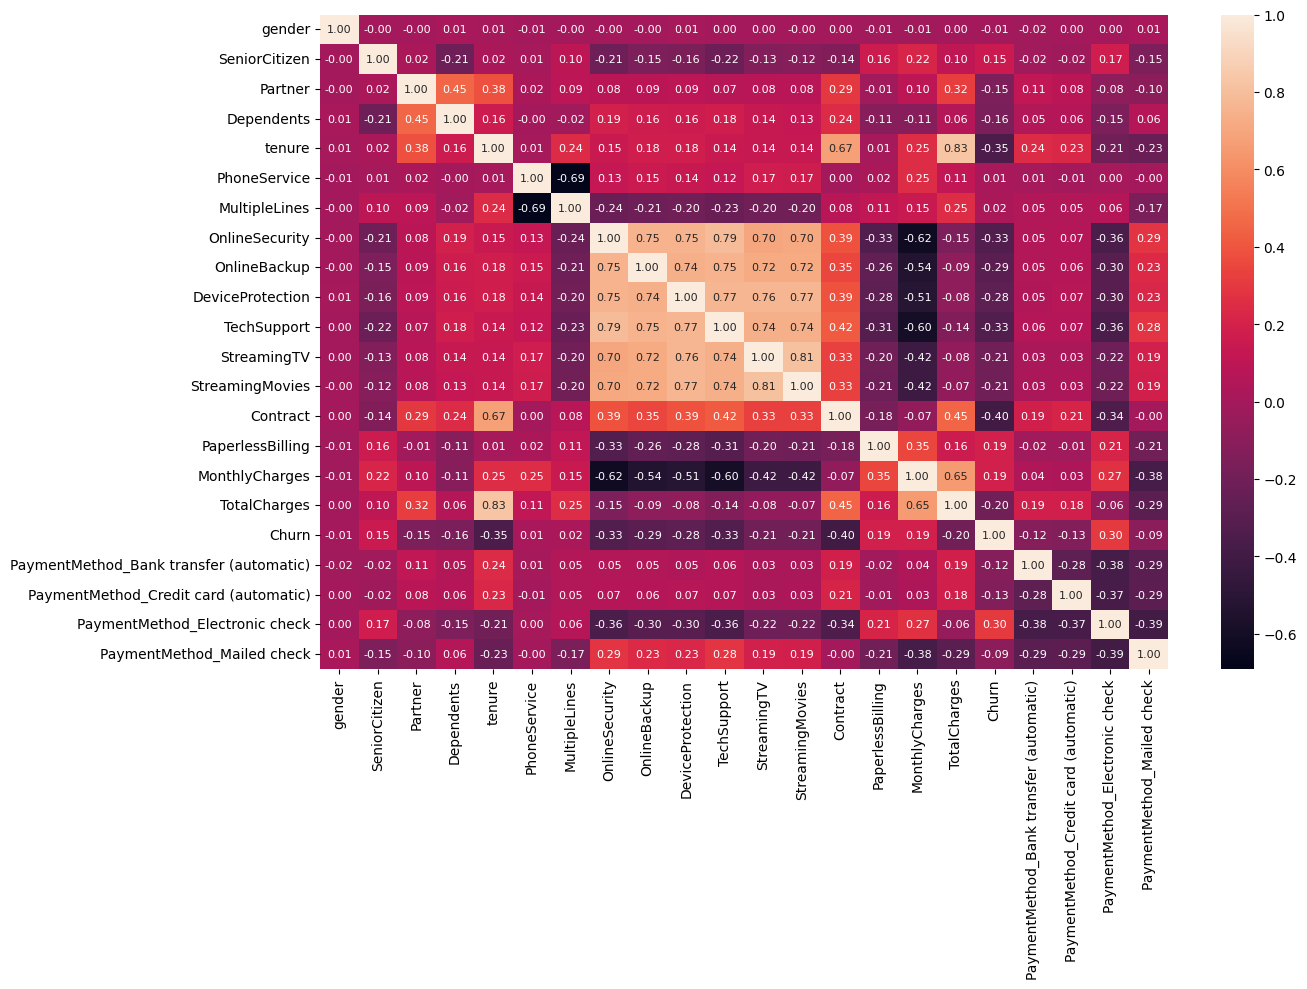

In [237]:
plt.figure(figsize=(14, 10))
sns.heatmap(nums_col_df.corr(), annot=True, fmt='.2f', cmap='rocket',
            annot_kws={"size": 8}, cbar=True)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

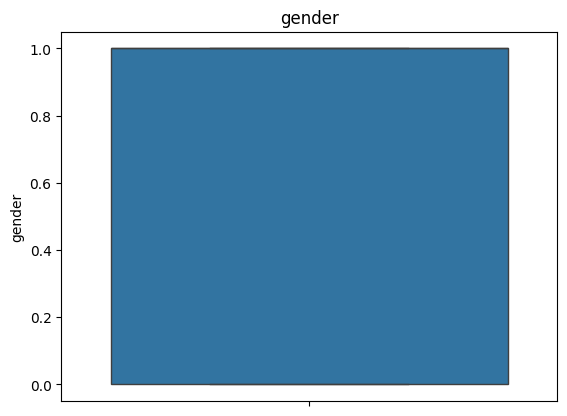

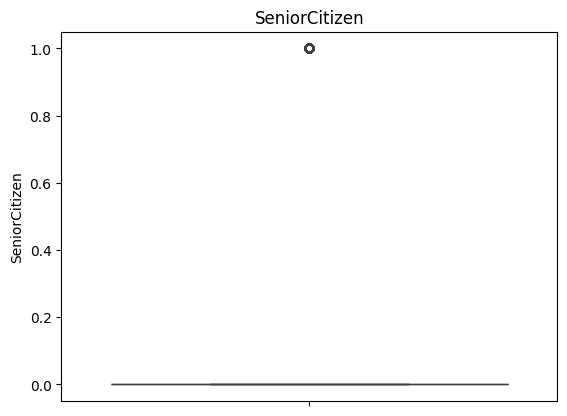

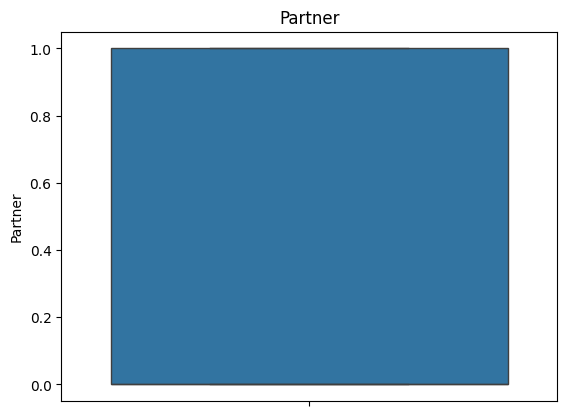

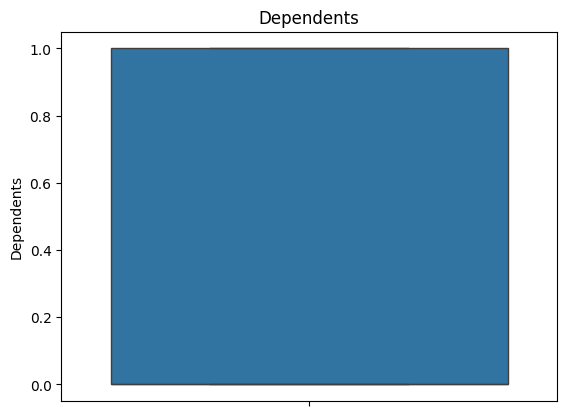

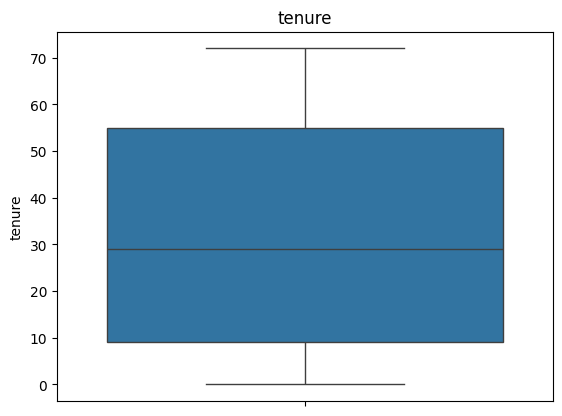

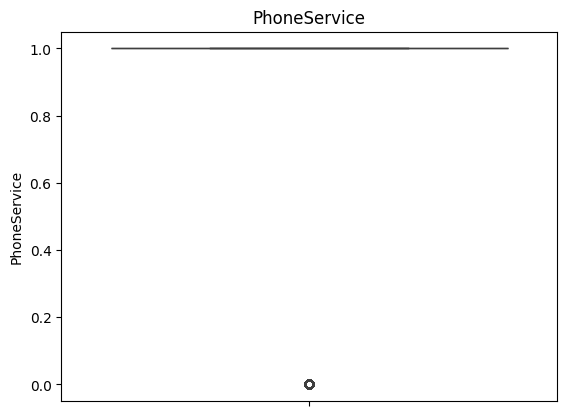

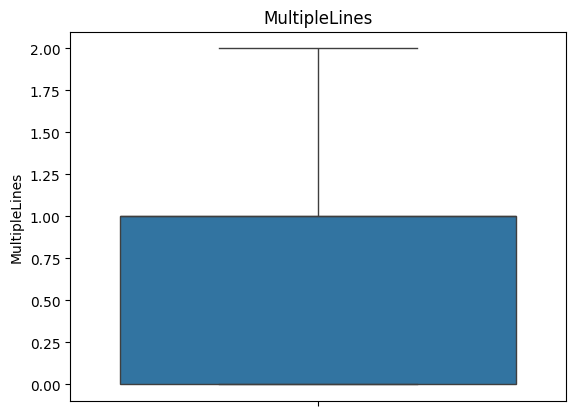

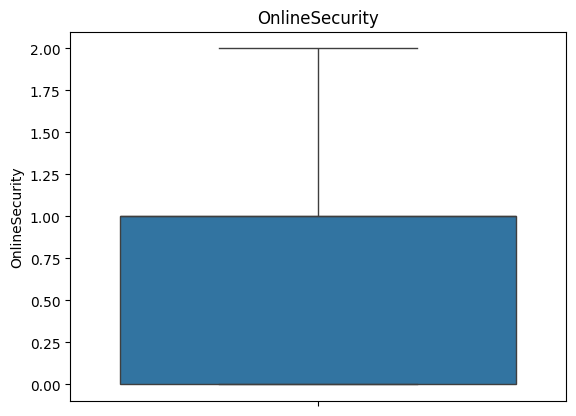

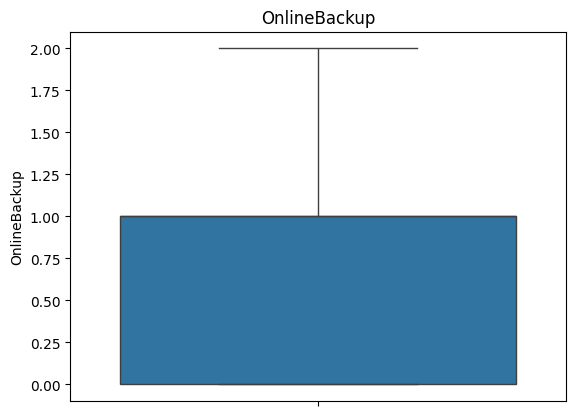

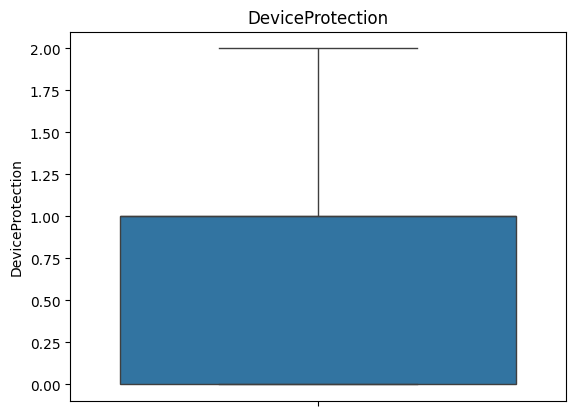

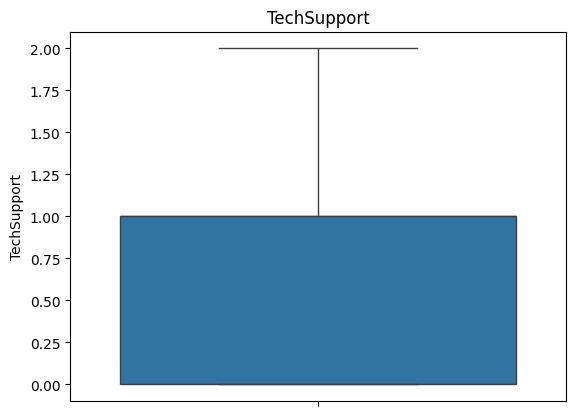

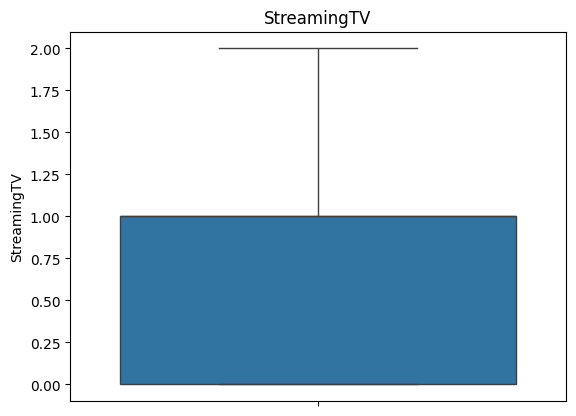

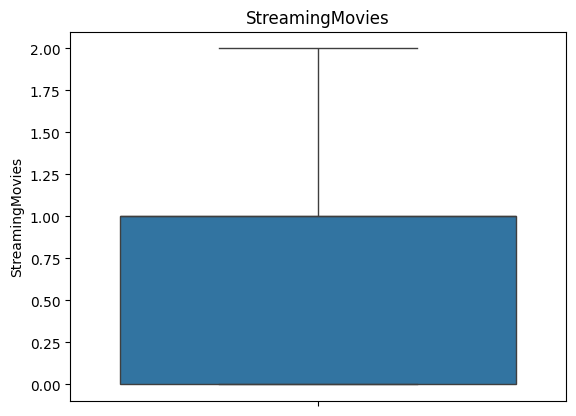

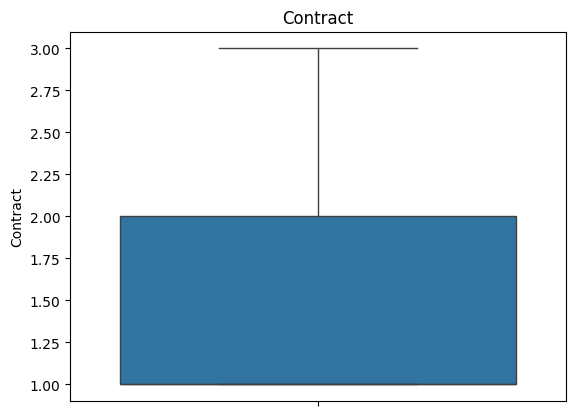

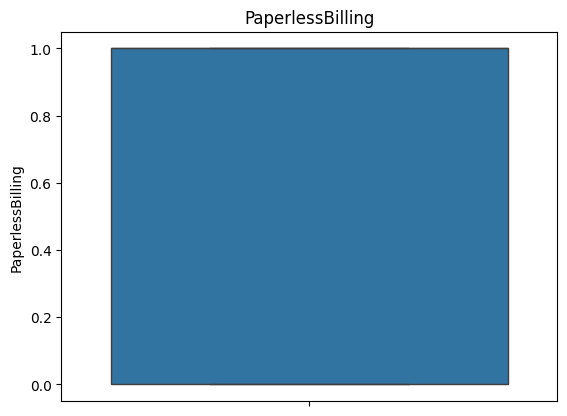

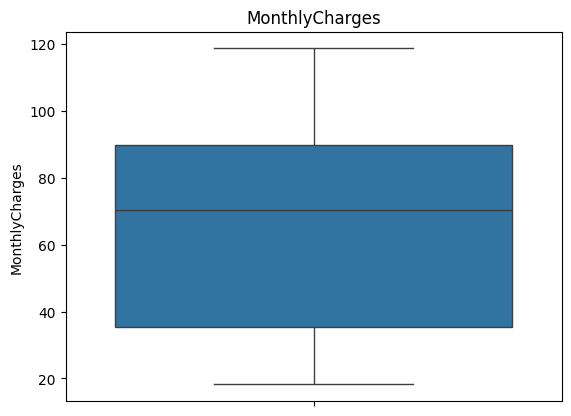

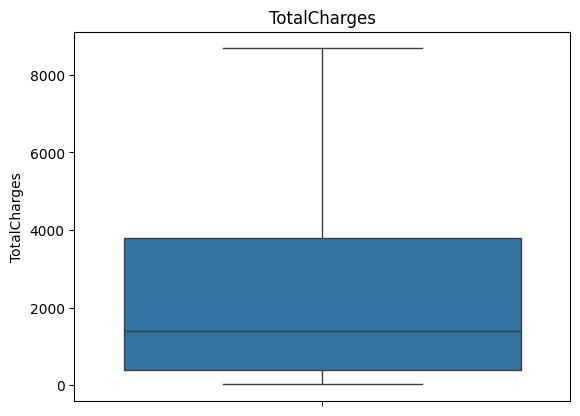

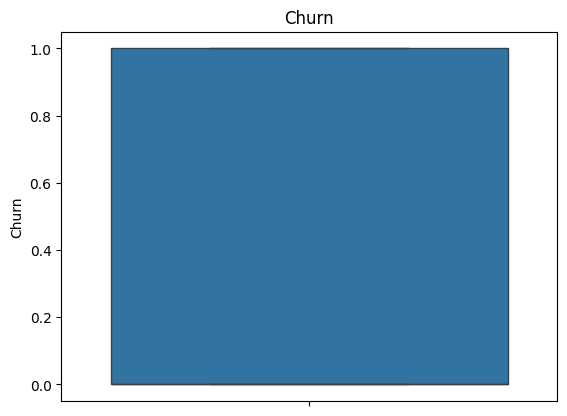

In [238]:
for col in num_cols:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [239]:
nums_col_df.loc[df['tenure']==0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
488,0,0,1,1,0,0,2,1,0,1,...,0,3,1,52.55,NaN,0,1.0,0.0,0.0,0.0
753,1,0,0,1,0,1,0,2,2,2,...,2,3,0,20.25,NaN,0,0.0,0.0,0.0,1.0
936,0,0,1,1,0,1,0,1,1,1,...,1,3,0,80.85,NaN,0,0.0,0.0,0.0,1.0
1082,1,0,1,1,0,1,1,2,2,2,...,2,3,0,25.75,NaN,0,0.0,0.0,0.0,1.0
1340,0,0,1,1,0,0,2,1,1,1,...,0,3,0,56.05,NaN,0,0.0,1.0,0.0,0.0
3331,1,0,1,1,0,1,0,2,2,2,...,2,3,0,19.85,NaN,0,0.0,0.0,0.0,1.0
3826,1,0,1,1,0,1,1,2,2,2,...,2,3,0,25.35,NaN,0,0.0,0.0,0.0,1.0
4380,0,0,1,1,0,1,0,2,2,2,...,2,3,0,20.00,NaN,0,0.0,0.0,0.0,1.0
5218,1,0,1,1,0,1,0,2,2,2,...,2,2,1,19.70,NaN,0,0.0,0.0,0.0,1.0
6670,0,0,1,1,0,1,1,0,1,1,...,0,3,0,73.35,NaN,0,0.0,0.0,0.0,1.0


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   InternetService                          7043 non-null   object 
 8   OnlineSecurity                           7043 non-null   int64  
 9   OnlineBackup                             7043 non-null   int64  
 10  DeviceProtection                         7043 no

In [241]:
nums_col_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

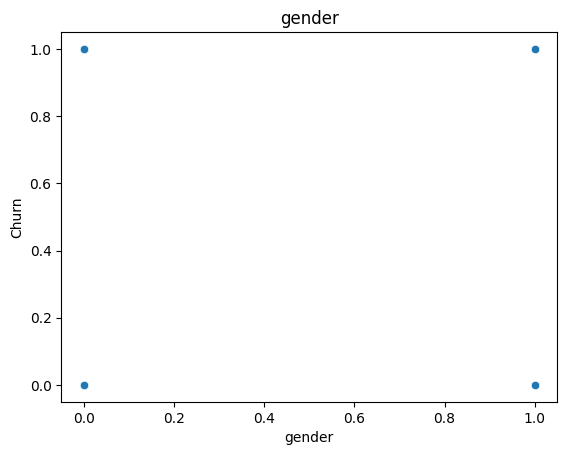

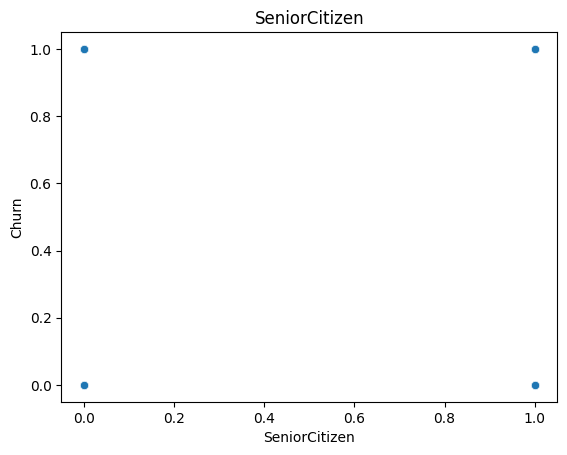

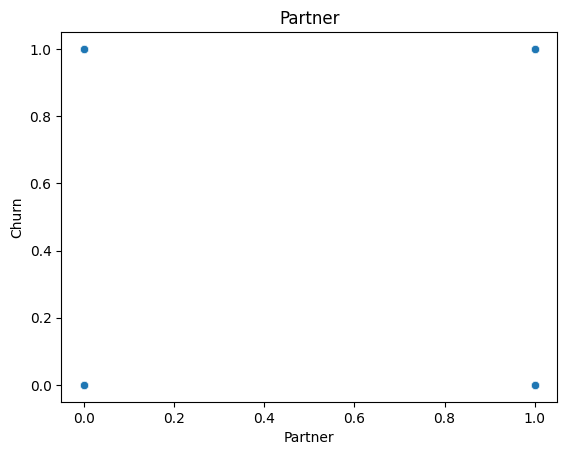

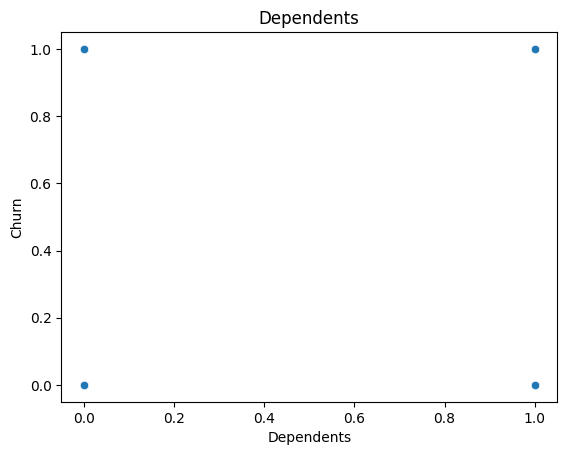

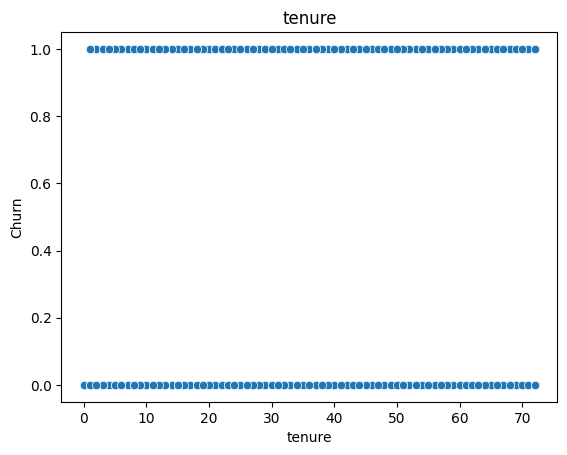

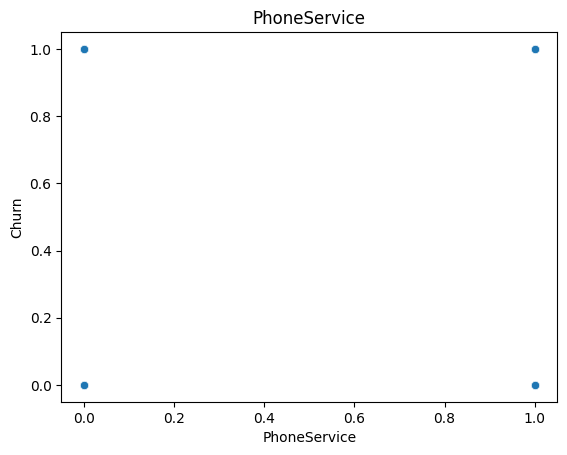

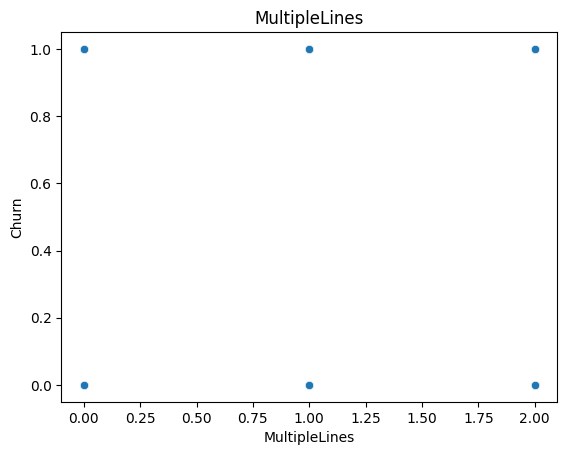

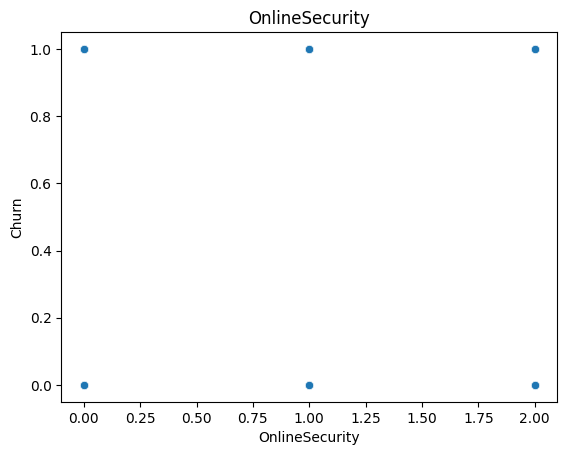

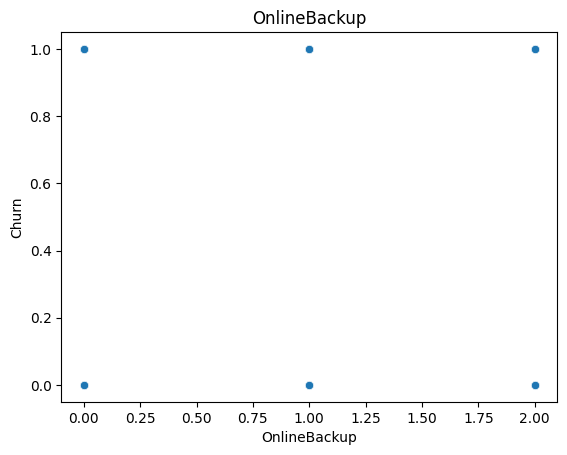

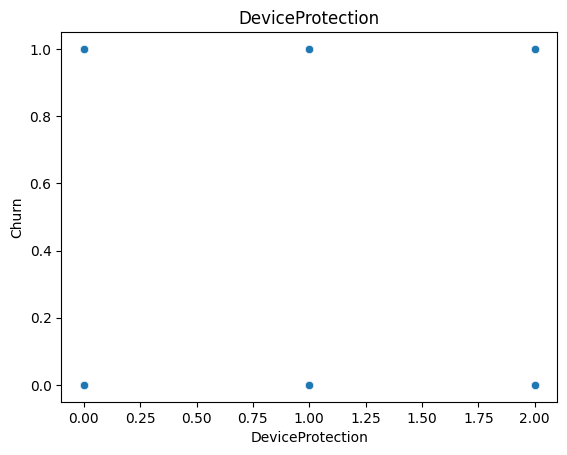

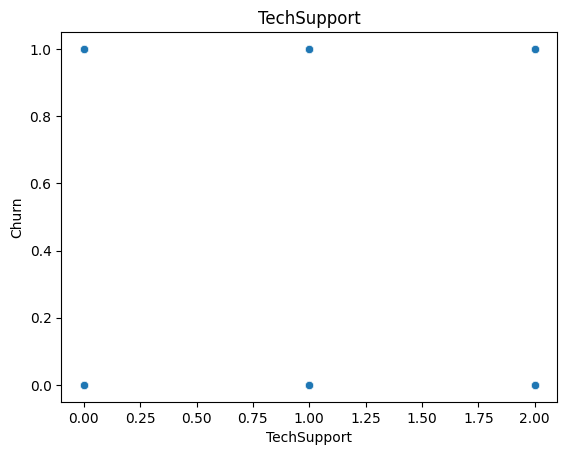

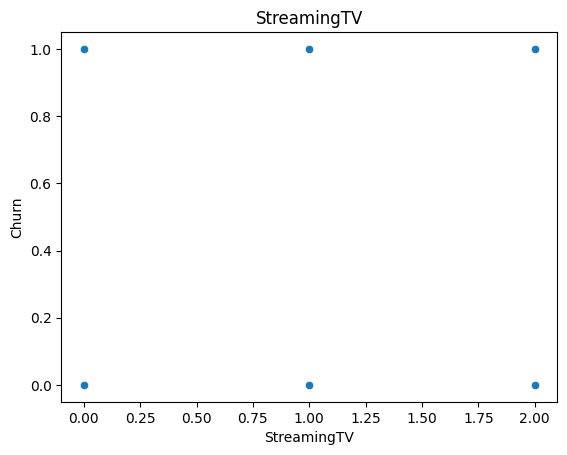

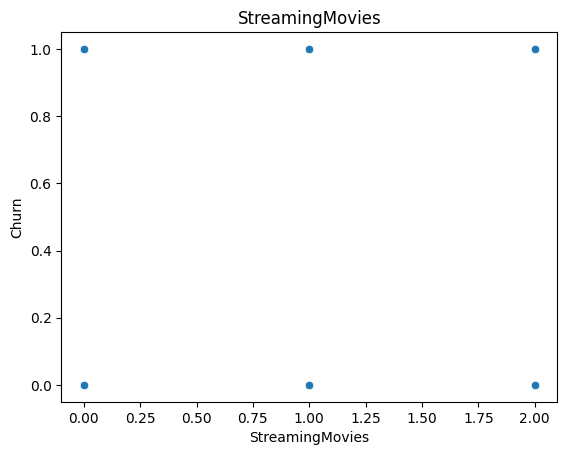

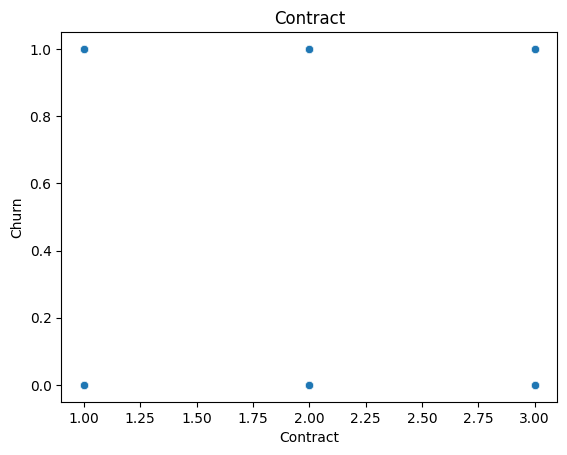

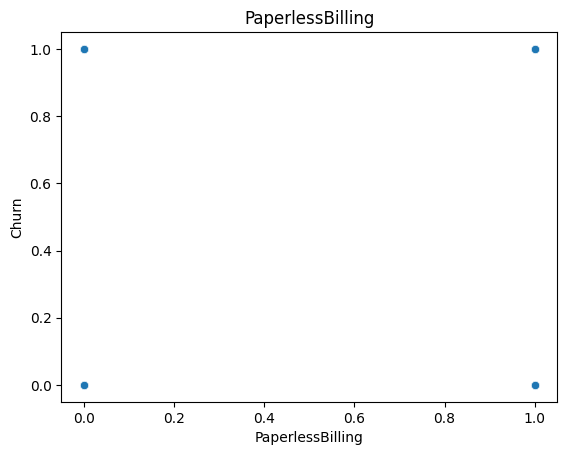

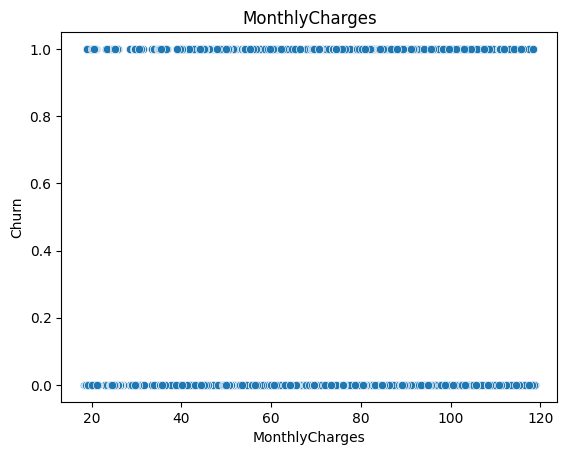

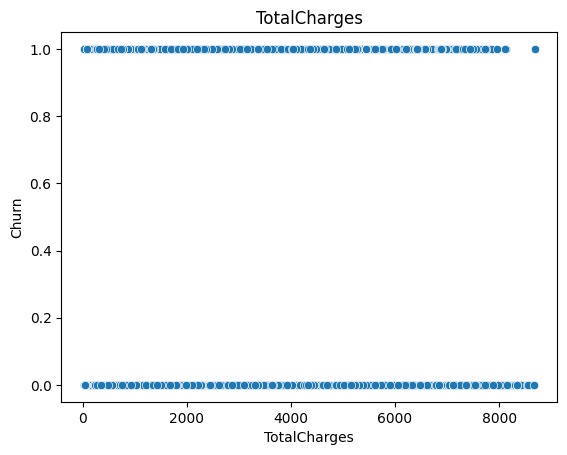

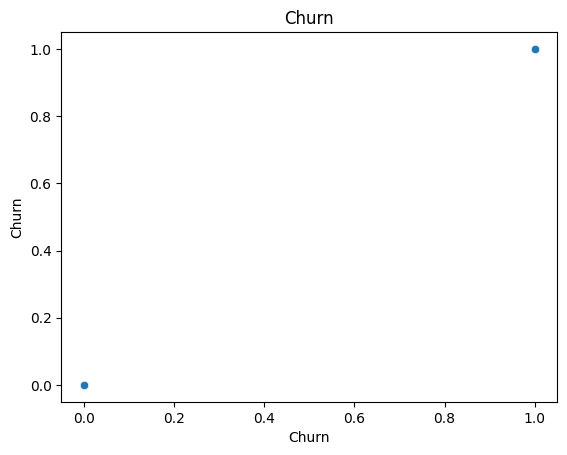

In [242]:
for col in num_cols:
  sns.scatterplot(y=nums_col_df['Churn'],x=nums_col_df[col])
  plt.title(col)
  plt.show()

<Axes: xlabel='tenure', ylabel='Churn'>

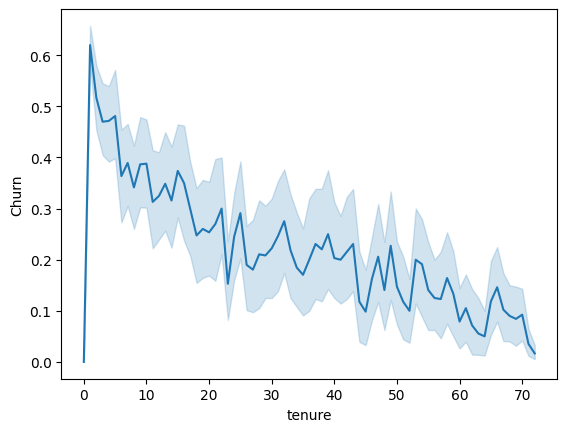

In [243]:
sns.lineplot(
    data=nums_col_df,
    x="tenure",
    y="Churn"
)

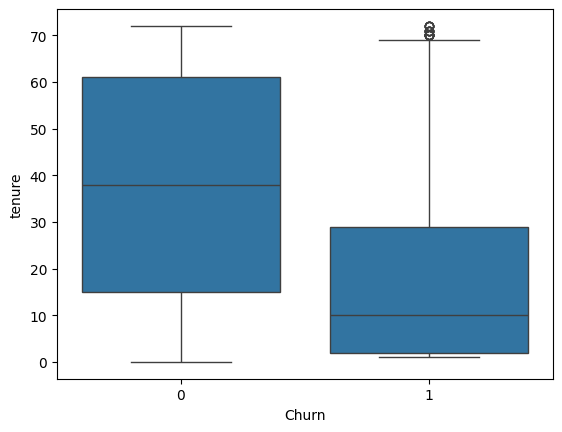

In [244]:
sns.boxplot(data=nums_col_df, x="Churn", y="tenure")
plt.show()

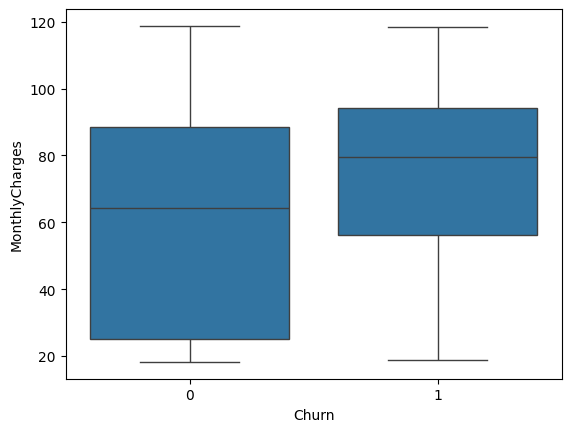

In [245]:
sns.boxplot(data=nums_col_df, x="Churn", y="MonthlyCharges")
plt.show()

In [246]:
nums_col_df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


In [247]:
nums_col_df.drop(columns=['TotalCharges'], inplace=True)

In [248]:
nums_col_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,Churn,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,2,0,1,0,...,0,0,1,1,29.85,0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,1,0,1,...,0,0,2,0,56.95,0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,0,1,1,0,...,0,0,1,1,53.85,1,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,2,1,0,1,...,0,0,2,0,42.30,0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,0,0,0,0,...,0,0,1,1,70.70,1,0.0,0.0,1.0,0.0


In [249]:
nums_col_df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [250]:
y= nums_col_df['Churn']
X= nums_col_df.drop('Churn', axis=1)

In [253]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1036
           1       0.66      0.57      0.61       373

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [254]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6573208722741433
Recall: 0.5656836461126006
F1 Score: 0.6080691642651297


In [256]:
from sklearn.metrics import precision_score, recall_score, f1_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print()

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Precision: 0.6774193548387096
Recall: 0.5630026809651475
F1 Score: 0.6149341142020498

Naive Bayes
Precision: 0.4818181818181818
Recall: 0.8525469168900804
F1 Score: 0.6156824782187803

KNN
Precision: 0.625
Recall: 0.4289544235924933
F1 Score: 0.5087440381558028

Decision Tree
Precision: 0.5
Recall: 0.4959785522788204
F1 Score: 0.4979811574697174

Random Forest
Precision: 0.6402877697841727
Recall: 0.4772117962466488
F1 Score: 0.5468509984639017

Adaboost
Precision: 0.6573208722741433
Recall: 0.5656836461126006
F1 Score: 0.6080691642651297



In [257]:
from sklearn.metrics import precision_score, recall_score, f1_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred, average=None)
    recall = recall_score(y_test, y_pred, average=None)
    f1 = f1_score(y_test, y_pred)

    print(name)
    print("Precision Class 0:", precision[0])
    print("Precision Class 1:", precision[1])
    print("Recall Class 0:", recall[0])
    print("Recall Class 1:", recall[1])
    print("F1 Score:", f1)
    print()

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Precision Class 0: 0.8516833484986351
Precision Class 1: 0.6774193548387096
Recall Class 0: 0.9034749034749034
Recall Class 1: 0.5630026809651475
F1 Score: 0.6149341142020498

Naive Bayes
Precision Class 0: 0.9265687583444593
Precision Class 1: 0.4818181818181818
Recall Class 0: 0.6698841698841699
Recall Class 1: 0.8525469168900804
F1 Score: 0.6156824782187803

KNN
Precision Class 0: 0.8152645273200347
Precision Class 1: 0.625
Recall Class 0: 0.9073359073359073
Recall Class 1: 0.4289544235924933
F1 Score: 0.5087440381558028

Decision Tree
Precision Class 0: 0.8163265306122449
Precision Class 1: 0.4842105263157895
Recall Class 0: 0.8108108108108109
Recall Class 1: 0.4932975871313673
F1 Score: 0.48871181938911024

Random Forest
Precision Class 0: 0.8277385159010601
Precision Class 1: 0.6425992779783394
Recall Class 0: 0.9044401544401545
Recall Class 1: 0.4772117962466488
F1 Score: 0.5476923076923077

Adaboost
Precision Class 0: 0.8511029411764706
Precision Class 1: 0.